# 0.0 Initial setting
## 0.1 Python's Libraries Imports

In [1]:
import mysql.connector
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats.mstats import winsorize

## Data Import

In [2]:
data_dir = Path("../Data")
input_file = data_dir / "2026-06-29_bank_dataset_raw.csv"

df = pd.read_csv(input_file, encoding="utf-8-sig")

print(f"Dataset loaded from: {input_file.resolve()}")
print(f"Shape: {df.shape}")

df.head(10)

Dataset loaded from: C:\Users\elisa\Documents\Simulador\ProjecteData\Equip_32\Data\2026-06-29_bank_dataset_raw.csv
Shape: (10642, 18)


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
5,6,42.0,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
6,7,56.0,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
7,8,60.0,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
8,9,37.0,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes
9,10,28.0,services,single,secondary,no,5090,yes,no,unknown,6,may,1297,3,-1,0,unknown,yes


## 0.3 Hue Style

In [3]:
# General graph style

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

# 3. Data Cleaning

## 3.1 Handling Null Demographic Values
Rows with missing values in 'marital', and 'education' were removed. Since they account for less than 5% of the dataset, they can be safely discarded.
Missing Value Imputation: Missing values in numerical variables 'age' was imputed using the median, as it is a robust measure that is less affected by outliers.

In [4]:
DC_df = df.dropna(subset=['marital', 'education'])

In [5]:
DC_df['age'] = DC_df['age'].fillna(DC_df['age'].median())

## 3.2 Review and Fix inconsistent values

In [6]:
print(DC_df['age'].min(), DC_df['age'].max())

18.0 95.0


The age variable was examined for inconsistent values. The observed range was 18 to 95 years, which is considered plausible for banking customers. Therefore, no records were removed based on age, as no unrealistic or invalid values were identified

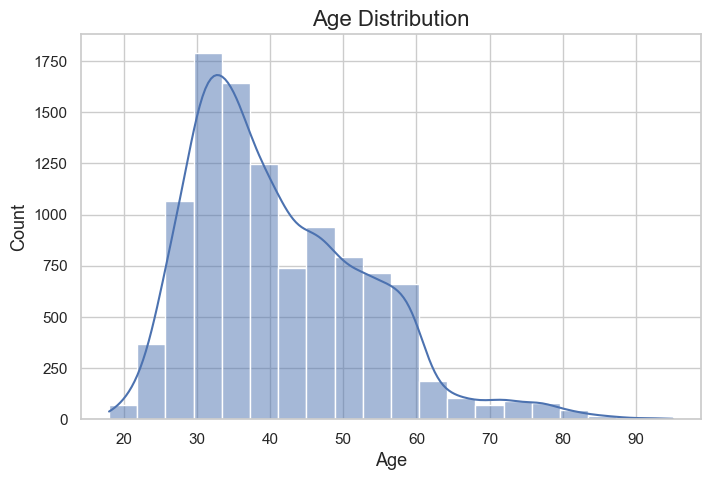

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(DC_df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

## 3.3 Data types and categories
Ensure numeric columns are correctly typed: age, balance, day, duration, campaign, pdays, previous should all be numeric (int/float) and not strings.
Standardize categorical values where there are only a few discrete options (marital, education, job, default, housing, loan, contact, month, poutcome, deposit) and check that there are no accidental extra categories like misspellings or inconsistent capitalization.

In [8]:
#  numeric columns
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

#  categorical columns
categorical_cols = ['job', 'marital', 'education', 'default',
                    'housing', 'loan', 'contact', 'month',
                    'poutcome', 'deposit']

# Asignar tipos
DC_df[numeric_cols] = DC_df[numeric_cols].apply(pd.to_numeric)
DC_df[categorical_cols] = DC_df[categorical_cols].astype(str)

# Comprobar los tipos
print(DC_df.dtypes)

id             int64
age          float64
job              str
marital          str
education        str
default          str
balance        int64
housing          str
loan             str
contact          str
day            int64
month            str
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome         str
deposit          str
dtype: object


## 3.4 Duplicate
No duplicate rows or duplicate IDs were found (df.duplicated().sum() = 0 and df['id'].duplicated().sum() = 0). Consequently, no duplicate removal was necessary.

# 3.5 Outliers and Extreme Values

A comprehensive review of the dataset identified several extreme values across key numerical variables:

- **Balance:** Values range from **−6,847** to **81,204**.
- **Duration:** Call duration reaches a maximum of **3,881 seconds**.
- **Campaign:** The number of contacts during the campaign reaches a maximum of **63**.

These extreme values may represent valid customer behaviour rather than data-entry errors. Therefore, different treatment strategies were applied depending on the nature of each variable.

#### Data Preprocessing Strategy

- **Balance:** Outliers were retained because they represent legitimate customer financial situations and may contain valuable business information.

- **Duration** and **Campaign:** Instead of removing observations, the team applied **standard Winsorization** using the `scipy.stats.mstats.winsorize()` function. The lowest and highest **1%** of values were capped to reduce the influence of extreme observations while preserving all records in the dataset.

This approach improves the robustness of subsequent analyses without reducing the sample size or discarding potentially valuable customer information.


In [9]:
# Create a copy of the cleaned dataset

DC_df_winsorized = DC_df.copy()

In [10]:
# Apply Winsorization to selected variables

DC_df_winsorized["duration"] = winsorize(
    DC_df_winsorized["duration"],
    limits=[0.02, 0.02]
)

DC_df_winsorized["campaign"] = winsorize(
    DC_df_winsorized["campaign"],
    limits=[0.02, 0.02]
)

In [11]:
print("=" * 60)
print("OUTLIER TREATMENT USING STANDARD WINSORIZATION")
print("=" * 60)

for column in ["duration", "campaign"]:

    lower = DC_df[column].quantile(0.01)
    upper = DC_df[column].quantile(0.99)

    print(f"\nVariable: {column}")
    print(f"1st percentile : {lower:.2f}")
    print(f"99th percentile: {upper:.2f}")
    print("Winsorization applied to the lowest and highest 1% of values.")

print(f"\nRows before Winsorization : {len(DC_df)}")
print(f"Rows after Winsorization  : {len(DC_df_winsorized)}")
print(f"Rows removed              : {len(DC_df) - len(DC_df_winsorized)}")

OUTLIER TREATMENT USING STANDARD WINSORIZATION

Variable: duration
1st percentile : 14.00
99th percentile: 1591.10
Winsorization applied to the lowest and highest 1% of values.

Variable: campaign
1st percentile : 1.00
99th percentile: 13.00
Winsorization applied to the lowest and highest 1% of values.

Rows before Winsorization : 10630
Rows after Winsorization  : 10630
Rows removed              : 0


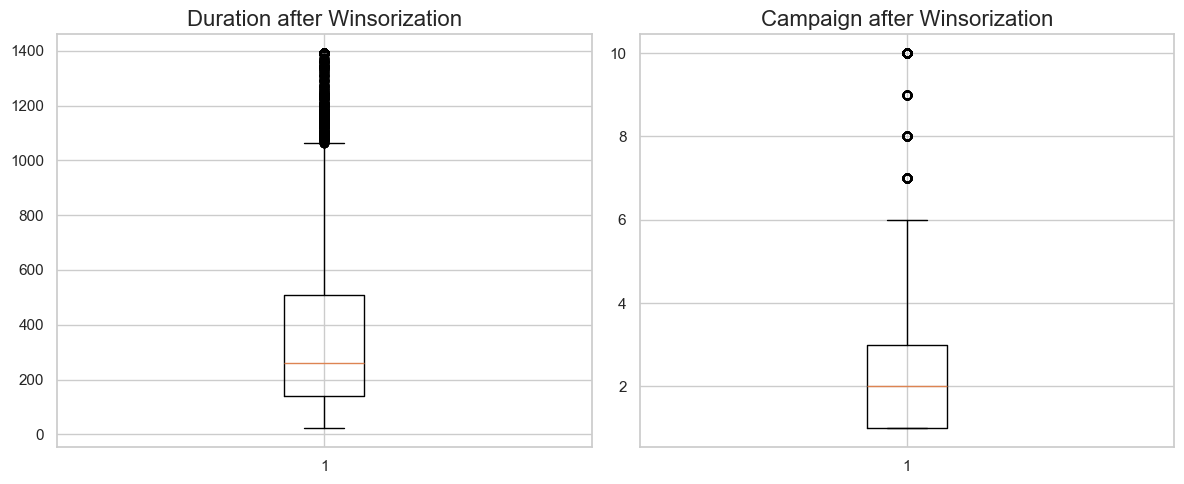

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(DC_df_winsorized["duration"])
axes[0].set_title("Duration after Winsorization")

axes[1].boxplot(DC_df_winsorized["campaign"])
axes[1].set_title("Campaign after Winsorization")

plt.tight_layout()
plt.show()

## 3.6 Target Variable Validation and Encoding
The target variable deposit was verified to contain two categories, no (5,353 observations) and yes (5,289 observations), indicating an almost balanced class distribution. For classification modeling, the variable was encoded as a binary target, with no = 0 and yes = 1.

In [13]:
# Display the frequency of each class
print(DC_df_winsorized['deposit'].value_counts())

# Display the class proportions
print(DC_df_winsorized['deposit'].value_counts(normalize=True))

# Convert the target variable to binary
DC_df_winsorized['deposit'] = DC_df_winsorized['deposit'].map({'no': 0, 'yes': 1})

# Verify the conversion
print(DC_df_winsorized['deposit'].value_counts())
print(DC_df_winsorized['deposit'].dtype)

deposit
no     5347
yes    5283
Name: count, dtype: int64
deposit
no     0.50301
yes    0.49699
Name: proportion, dtype: float64
deposit
0    5347
1    5283
Name: count, dtype: int64
int64


## 3.7 Handle Special Numeric Codes
Some numeric values in the dataset represent specific categories rather than true numerical measurements. To improve model interpretability, additional binary indicator variables were created to identify customers with no previous contact (pdays = -1) and customers who had at least one previous contact (previous > 0). The original variables were retained to preserve all available information for modeling.

In [14]:
# Create an indicator for customers with no previous contact
DC_df_winsorized['no_previous_contact'] = (DC_df_winsorized['pdays'] == -1).astype(int)

# Verify the new variable
print(DC_df_winsorized[['pdays', 'no_previous_contact']].head())

# Create an indicator for customers with previous contacts
DC_df_winsorized['had_previous_contact'] = (DC_df_winsorized['previous'] > 0).astype(int)

# Verify the new variable
print(DC_df_winsorized[['previous', 'had_previous_contact']].head())

   pdays  no_previous_contact
0     -1                    1
1     -1                    1
2     -1                    1
3     -1                    1
4     -1                    1
   previous  had_previous_contact
0         0                     0
1         0                     0
2         0                     0
3         0                     0
4         0                     0


In [15]:
DC_df_winsorized

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,no_previous_contact,had_previous_contact
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,1,1,0
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1391,1,-1,0,unknown,1,1,0
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,1,1,0
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,1,1,0
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10637,10638,33.0,technician,married,secondary,no,218,yes,yes,telephone,2,mar,169,4,-1,0,unknown,0,1,0
10638,10639,42.0,management,single,tertiary,no,1146,yes,no,unknown,15,may,98,2,-1,0,unknown,0,1,0
10639,10640,31.0,unemployed,single,unknown,no,167,no,no,cellular,20,nov,316,1,-1,0,unknown,0,1,0
10640,10641,30.0,blue-collar,single,secondary,yes,447,no,no,cellular,19,nov,426,2,189,6,failure,0,0,1


In [16]:
#  Export dataset to csv after cleaning process

# Create output directory if it doesn't exist
output_dir = Path("../Data")
output_dir.mkdir(parents=True, exist_ok=True)

# Export dataframe
output_file = output_dir / "2026-06-29_bank_dataset_cleaned.csv"
DC_df_winsorized.to_csv(output_file, index=False, encoding="utf-8")

print(f"CSV saved to: {output_file.resolve()}")

CSV saved to: C:\Users\elisa\Documents\Simulador\ProjecteData\Equip_32\Data\2026-06-29_bank_dataset_cleaned.csv
